# LEO Satellite Pass Predictor

This notebook uses TLE data and Skyfield to predict satellite visibility passes 
(AOS/LOS and max elevation) over a ground station (London).

Satellite: ISS (ZARYA)


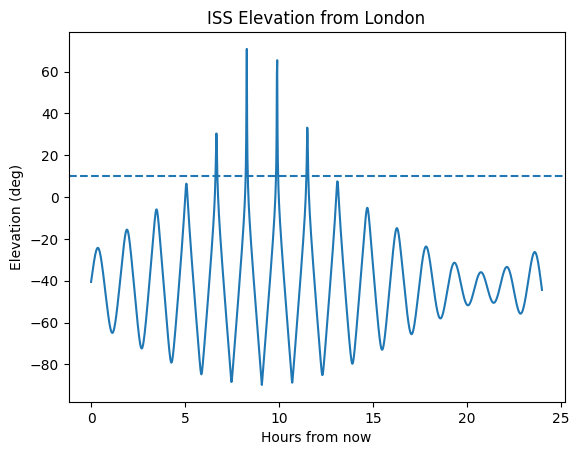

In [2]:
from skyfield.api import load, wgs84
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load satellite from TLE
ts = load.timescale()

sat = load.tle_file(
    "https://celestrak.org/NORAD/elements/stations.txt"
)[0]  # First satellite (ISS)

print("Satellite:", sat.name)

# Ground station (London)
gs = wgs84.latlon(51.5074, -0.1278)

# Time range (next 24 hours)
t0 = ts.now()
minutes = np.arange(0, 24*60, 1)
t = ts.utc(t0.utc_datetime() + pd.to_timedelta(minutes, unit="m"))

# Compute elevation
difference = sat - gs
topocentric = difference.at(t)
alt, az, distance = topocentric.altaz()

elevation = alt.degrees

# Plot elevation
plt.figure()
plt.plot(minutes/60, elevation)
plt.axhline(10, linestyle="--")
plt.xlabel("Hours from now")
plt.ylabel("Elevation (deg)")
plt.title("ISS Elevation from London")
plt.show()

In [3]:
min_el = 10
above = elevation >= min_el

passes = []
in_pass = False

for i in range(len(above)):
    if above[i] and not in_pass:
        aos = i
        in_pass = True
    elif not above[i] and in_pass:
        los = i
        in_pass = False
        passes.append((aos, los))

for idx, (aos, los) in enumerate(passes, 1):
    print(f"Pass {idx}")
    print("AOS:", t[aos].utc_iso())
    print("LOS:", t[los].utc_iso())
    print("Max elevation:", round(max(elevation[aos:los]),2))
    print()

Pass 1
AOS: 2026-03-03T23:22:18Z
LOS: 2026-03-03T23:28:18Z
Max elevation: 30.42

Pass 2
AOS: 2026-03-04T00:58:18Z
LOS: 2026-03-04T01:05:18Z
Max elevation: 70.87

Pass 3
AOS: 2026-03-04T02:35:18Z
LOS: 2026-03-04T02:41:18Z
Max elevation: 65.47

Pass 4
AOS: 2026-03-04T04:12:18Z
LOS: 2026-03-04T04:18:18Z
Max elevation: 33.2

